### Group No: 72
### Group Members Name with Student ID:
| Name        | BITS ID           | Contribution |
|-------------|--------------|--------------|
| MOHAN K R   | 2024AA05419  | 100%          |
| SATHWIK H R | 2024AA05903  | 100%          |
| T J SHREYAS | 2024AA05418  | 100%          |
| CHANDRA SEKHAR MAHANTA| 2024AA05902  | 100%         |
|   ATUL AGARWAL | 2023AC05656 | 100%         |

##Setup & Library Installation

In [3]:
# Install required libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow joblib fastapi uvicorn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.8 MB/s eta 0:00:00


##Data Acquisition (Automated Download)

In [4]:
import urllib.request

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

FILE_PATH = os.path.join(DATA_DIR, "heart_disease.csv")

urllib.request.urlretrieve(DATA_URL, FILE_PATH)

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(FILE_PATH, names=columns)

# Binary target
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


##Data Cleaning & Preprocessing

In [5]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert numeric columns
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

# Fill missing values with median
df.fillna(df.median(), inplace=True)

df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


##Exploratory Data Analysis (EDA)

###Visualizations:

####Class Balance

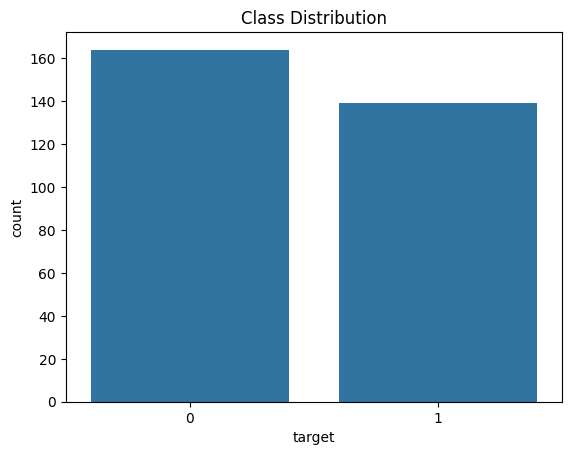

In [6]:
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.show()


####Feature Distributions

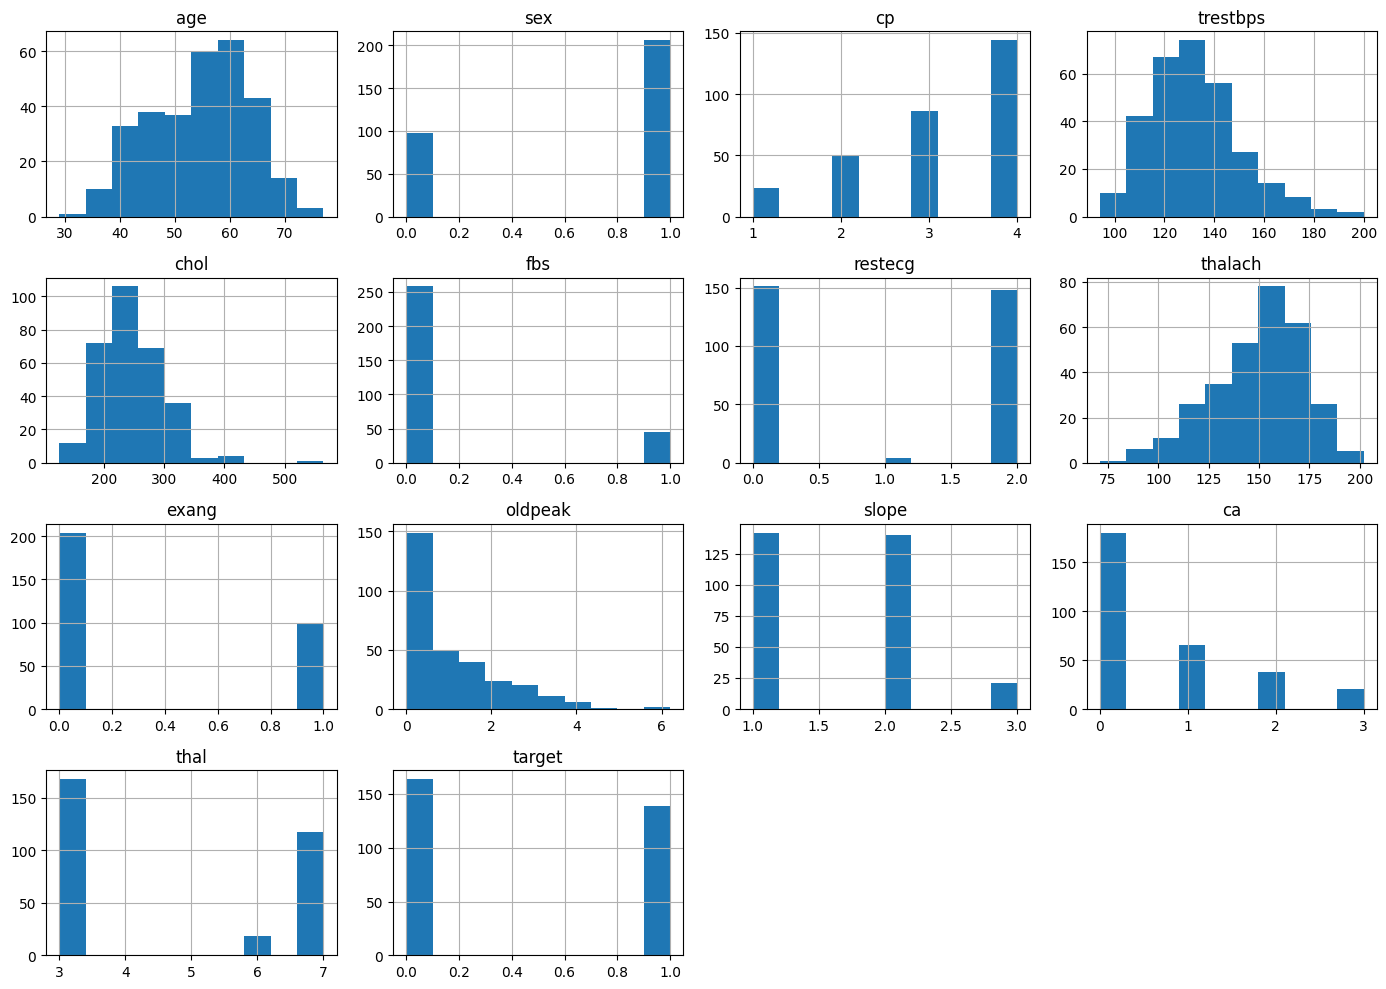

In [7]:
df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()


####Correlation Heatmap

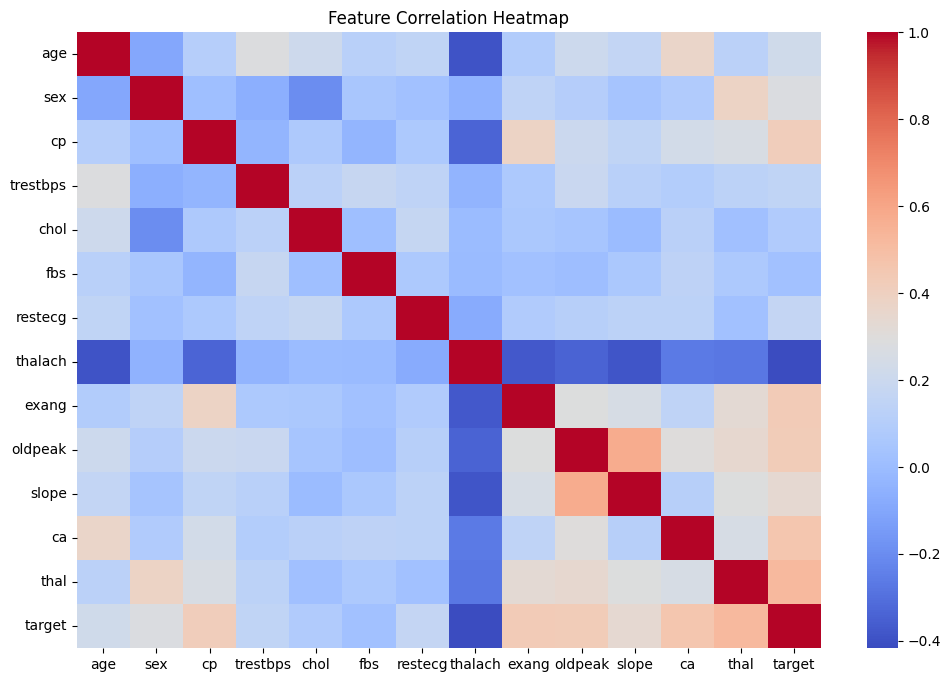

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


##Feature Engineering

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()


##Model Training (Logistic Regression)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.8688524590163934
ROC-AUC: 0.9512987012987013
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



##Model Training (Random Forest)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Accuracy: 0.8852459016393442
ROC-AUC: 0.9523809523809523


##Cross-Validation

In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring="roc_auc")
print("LogReg CV ROC-AUC:", cv_scores.mean())


LogReg CV ROC-AUC: 0.9011639209555877


##MLflow Experiment Tracking

In [13]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Heart Disease Prediction")

with mlflow.start_run(run_name="LogisticRegression"):
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob))
    mlflow.sklearn.log_model(log_reg, "model")

with mlflow.start_run(run_name="RandomForest"):
    mlflow.log_param("model", "RandomForest")
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_prob_rf))
    mlflow.sklearn.log_model(rf, "model")


2026/01/06 00:28:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/06 00:28:08 INFO mlflow.store.db.utils: Updating database tables
2026/01/06 00:28:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/06 00:28:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/06 00:28:09 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/06 00:28:10 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/01/06 00:28:10 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/01/06 00:28:10 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/01/06 00:28:10 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/01/06 00:28:10 INFO alembic.runtime.migration: Running 

##Model Packaging

In [14]:
import joblib

os.makedirs("artifacts", exist_ok=True)
joblib.dump(log_reg, "artifacts/heart_model.pkl")

print("Model saved for deployment")


Model saved for deployment


##requirements.txt Generator

In [15]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
mlflow
joblib
fastapi
uvicorn
matplotlib
seaborn


Writing requirements.txt


##Unit Test Example

In [16]:
%%writefile test_model.py
import joblib

def test_model_load():
    model = joblib.load("artifacts/heart_model.pkl")
    assert model is not None


Writing test_model.py


##FastAPI Inference API

In [17]:
%%writefile app.py
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()
model = joblib.load("artifacts/heart_model.pkl")

@app.post("/predict")
def predict(data: list):
    pred = model.predict([data])[0]
    prob = model.predict_proba([data])[0][1]
    return {"prediction": int(pred), "confidence": float(prob)}


Writing app.py


##Dockerfile

In [18]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app
COPY requirements.txt .
RUN pip install -r requirements.txt

COPY artifacts artifacts
COPY app.py .

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]


Overwriting Dockerfile


##Kubernetes Deployment YAML

In [19]:
%%writefile deployment.yaml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: heart-api
spec:
  replicas: 1
  selector:
    matchLabels:
      app: heart
  template:
    metadata:
      labels:
        app: heart
    spec:
      containers:
      - name: heart-api
        image: heart-api:latest
        ports:
        - containerPort: 8000


Writing deployment.yaml


##Monitoring & Logging

In [20]:
import logging

logging.basicConfig(level=logging.INFO)
logging.info("API Request received")
